# MODELADO IRAIA

In [53]:
# Cargar librerias
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
np.random.seed(0)
import os

In [ ]:
# Cargar datos
df = pd.read_csv("df_limpio_con_clusters.csv", sep=",", low_memory=False)

df_tiempo = pd.read_csv("datos_meteorologicos_2023.csv")


In [55]:
#Tamaño
print(df.shape)
print(df_tiempo.shape)

(105457, 46)


NameError: name 'df_tiempo' is not defined

In [ ]:
#Tipo de variables
print(df.dtypes)
print(df_tiempo.dtypes)

booked_at                          object
checkin_time                       object
lead_time                          object
lenght_of_stay                     object
checkin_month                      object
checkin_day                        object
adult_count                        object
child_count                        object
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                    object
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count        object
all_entry_forms_completed          object
returning_inhabitant               object
recurrence                        

In [ ]:
#Pasar las variables booleanas a numericas:
#df['all_entr_forms_num'] = df['all_entry_forms_completed'].map({'yes': 1, 'no': 0})
#df["bought_products_num"] = df['bought_products'].map({'yes': 1, 'no': 0})

In [ ]:

#???????????????????????????????????
# Convertir a numerico:
# Convertir las columnas numéricas que están como object a float/int
cols_to_numeric = ['lead_time', 'lenght_of_stay', 'adult_count', 'child_count',
                   'available_units', 'completed_entry_forms_count',
                   'all_entr_forms_num', 'bought_products_num', 'product_count',
                   'reservation_net_value', 'total_adr', 'cancellation_lead_time',
                   'total_personas_adult_y_niños', 'ratio_formularios',
                   'reservation_checkin_month_diff', 'mes_checkin_numerico',
                   'estancia_en_finde']  # ajusta según tus columnas

for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # convierte, NaN si hay error



In [ ]:
#Visualizar las primeras 10 filas:
df.head(10)
df_tiempo.head(10)

NameError: name 'df_tiempo' is not defined

Correlacion de las variables:

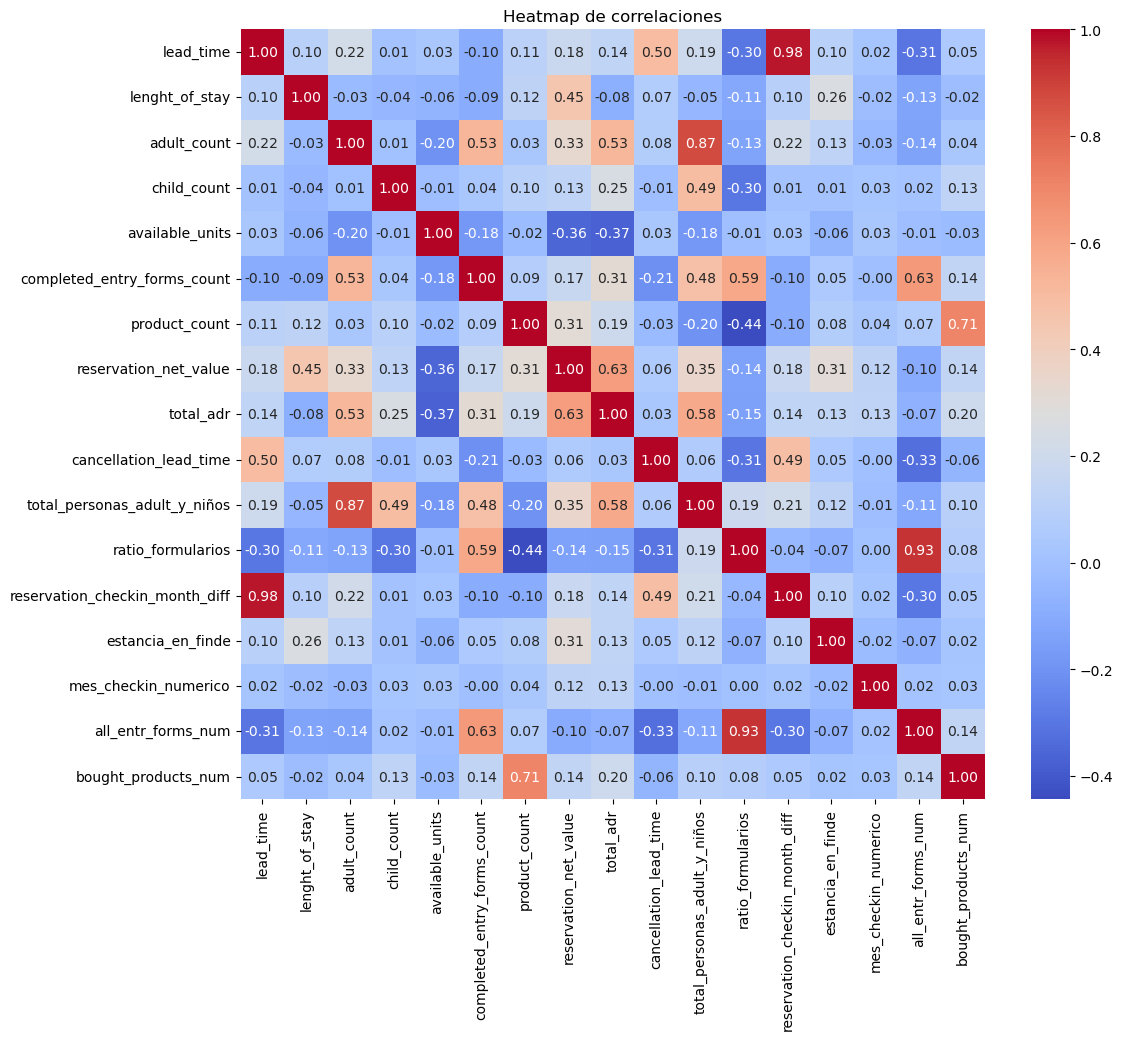

In [59]:

# 2. Seleccionar solo las columnas numéricas
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 3. Calcular la matriz de correlación
corr_matrix = numeric_df.corr()

# 4. Graficar el heatmap
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,      # matriz de correlación
    annot=True,       # mostrar los valores dentro de los cuadros
    fmt=".2f",        # formato de los números
    cmap="coolwarm",  # mapa de colores
    cbar=True         # mostrar barra de color
)
plt.title("Heatmap de correlaciones")
plt.show()


In [61]:
df["status"].unique()

array(['checked_out', 'cancelled', nan, 'cancellation_lead_time', '0.0',
       '33.0', '30.0', '1.0', '9.0', '12.0', '43.0', '4.0', '2.0', '17.0',
       '59.0', '7.0', '3.0', '49.0', '26.0', '34.0', '6.0', '31.0',
       '66.0', '46.0', '15.0', '5.0', '22.0', '11.0', '28.0', '38.0',
       '23.0', '25.0', '64.0', '13.0', '45.0', '93.0', '108.0', '79.0',
       '103.0', '90.0', '75.0', '39.0', '106.0', '74.0', '14.0', '73.0',
       '27.0', '10.0', '78.0', '53.0', '19.0', '20.0', '57.0', '42.0',
       '16.0', '18.0', '100.0', '8.0', '36.0', '37.0', '67.0', '95.0',
       '162.0', '92.0', '54.0', '99.0', '58.0', '51.0', '252.0', '24.0',
       '200.0', '29.0', '112.0', '230.0', '167.0', '21.0', '127.0',
       '245.0', '32.0', '143.0', '35.0', '289.0', '193.0', '62.0', '48.0',
       '72.0', '179.0', '113.0', '115.0', '116.0', '71.0', '296.0',
       '47.0', '311.0', '161.0', '234.0', '194.0', '56.0', '40.0',
       '315.0', '322.0', '317.0', '44.0', '135.0', '117.0', '126.0',
       

In [60]:
# Que variables escogeremos? Las que tengan gran correalcion con la varibale objetivo ("STATUS")

# Analizamos las correlaciones ABSOLUTA con la variable objetivo (STATUS)
corr_medv = corr_matrix["status"].abs()
corr_medv_ordenado = corr_medv.sort_values(ascending= False)
print(corr_medv_ordenado)
# Seleccionar umbral
umbral = 0.4

# Variables relevantes
vars_relevantes = corr_medv[corr_medv > umbral].index.tolist()
vars_relevantes

KeyError: 'status'